In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [54]:
enc = OrdinalEncoder(categories=[['no','local','generalized']])
enc.fit([['no'], ['local'], ['generalized']])                                 
df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
df2["Peritonitis"].value_counts(dropna = False)

0.0    189
1.0     43
2.0      6
Name: Peritonitis, dtype: int64

In [55]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.1618742249964222

In [56]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!=0).astype(int)

In [57]:
#dropping the Peritonitis Columns
df2.drop(["Peritonitis"],axis=1, inplace =True)

In [58]:
# df2["Diagnosis"].corr(df2["Peritonitis_binary"])

In [59]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [60]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [61]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [62]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [64]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

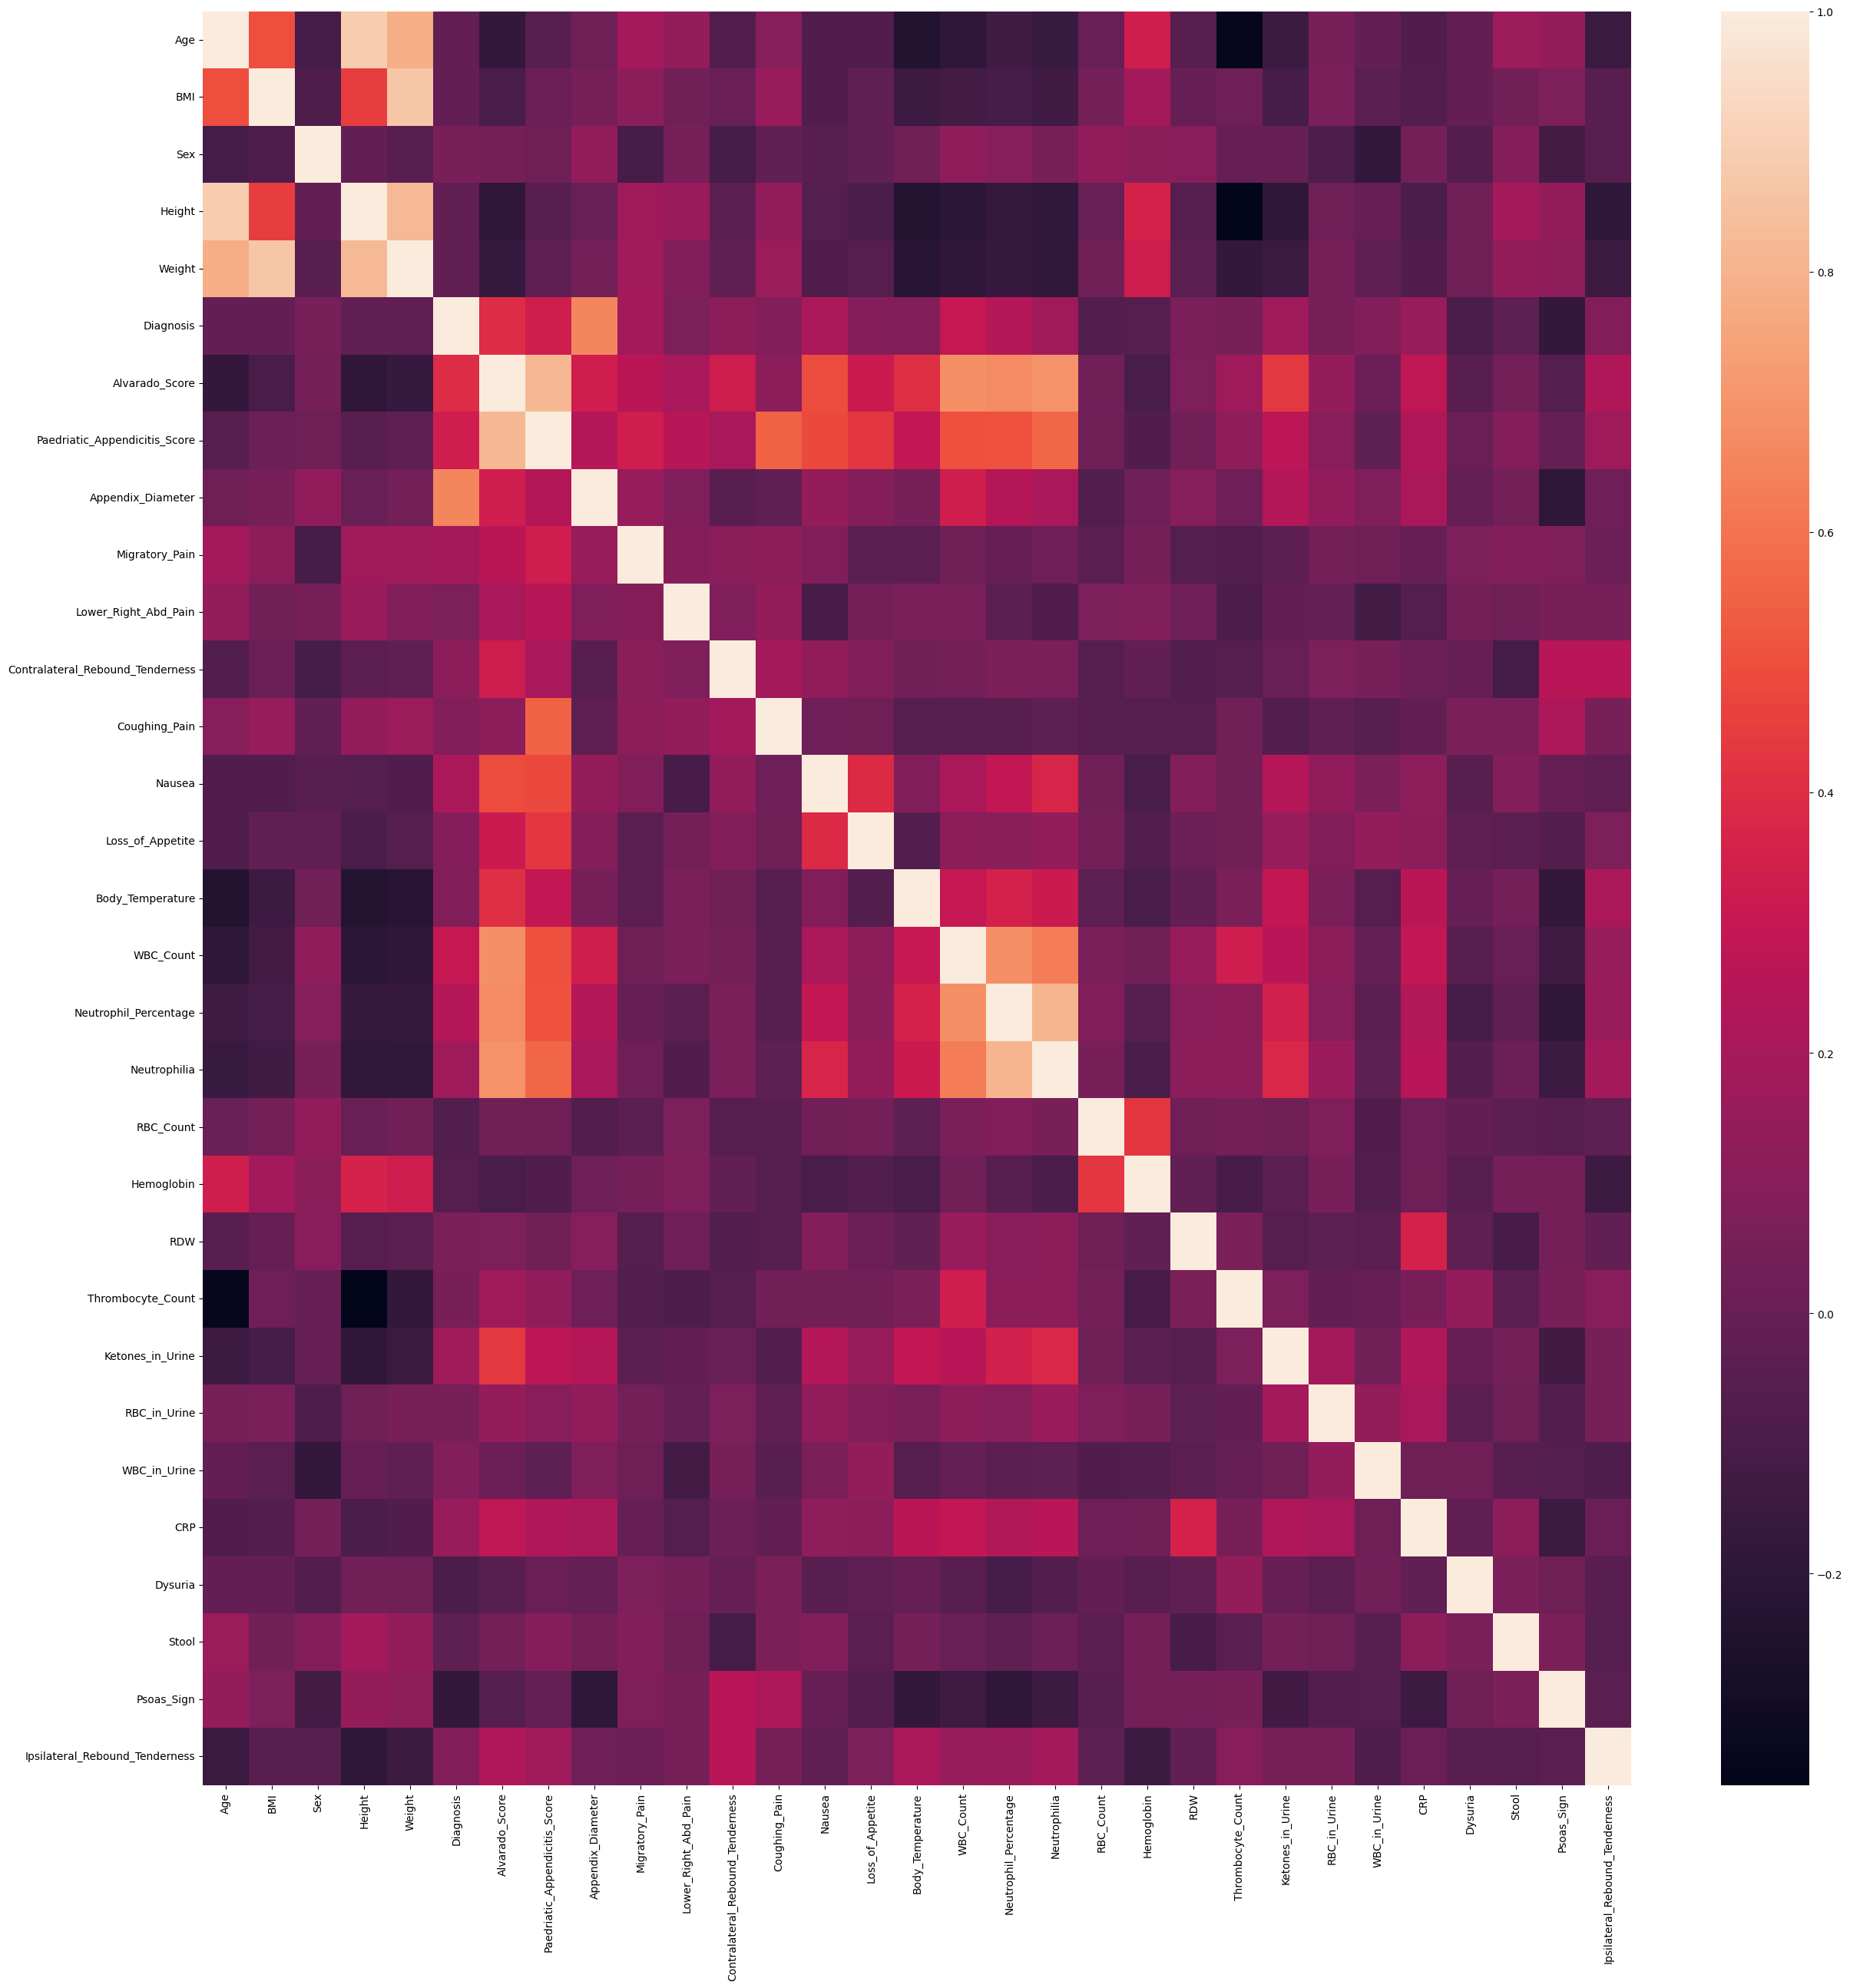

In [65]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [66]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [67]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [68]:
# dsafsf

In [69]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 31)

# APPLYING FISHER SCORE FOR FEATURE SELECTION

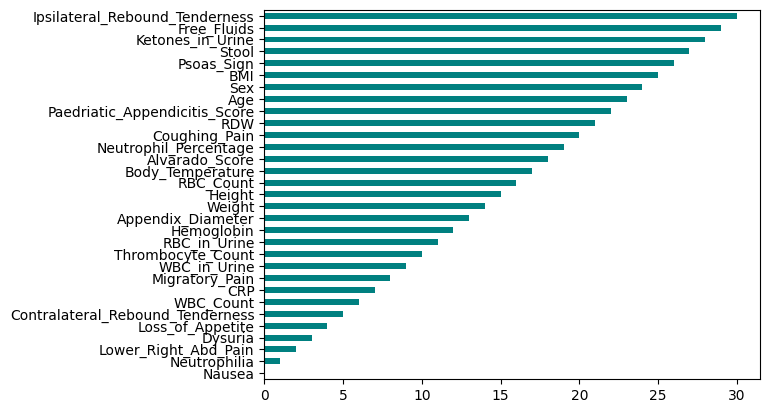

In [70]:
# pip install skfeature-chappers
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks>5]

In [71]:
cols

array([23, 25, 24, 15, 14, 18, 22, 13,  8, 20, 17,  6, 19, 16, 12, 21, 10,
       28, 11,  9,  7, 27, 26, 30, 29])

In [72]:
x_fs= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs.columns)

The features retained after using this techniques are :
Index(['RBC_in_Urine', 'CRP', 'WBC_in_Urine', 'WBC_Count', 'Body_Temperature',
       'RBC_Count', 'Ketones_in_Urine', 'Loss_of_Appetite', 'Migratory_Pain',
       'RDW', 'Neutrophilia', 'Paedriatic_Appendicitis_Score', 'Hemoglobin',
       'Neutrophil_Percentage', 'Nausea', 'Thrombocyte_Count',
       'Contralateral_Rebound_Tenderness', 'Psoas_Sign', 'Coughing_Pain',
       'Lower_Right_Abd_Pain', 'Appendix_Diameter', 'Stool', 'Dysuria',
       'Free_Fluids', 'Ipsilateral_Rebound_Tenderness'],
      dtype='object')


In [73]:
# ruk jaaaa ae dil diwaaaane
x_fs.shape

(238, 25)

In [74]:
print(cols)
col = x.iloc[:,cols]
col = col.columns
col = list(col)
col.append("Diagnosis")
print(col)

[23 25 24 15 14 18 22 13  8 20 17  6 19 16 12 21 10 28 11  9  7 27 26 30
 29]
['RBC_in_Urine', 'CRP', 'WBC_in_Urine', 'WBC_Count', 'Body_Temperature', 'RBC_Count', 'Ketones_in_Urine', 'Loss_of_Appetite', 'Migratory_Pain', 'RDW', 'Neutrophilia', 'Paedriatic_Appendicitis_Score', 'Hemoglobin', 'Neutrophil_Percentage', 'Nausea', 'Thrombocyte_Count', 'Contralateral_Rebound_Tenderness', 'Psoas_Sign', 'Coughing_Pain', 'Lower_Right_Abd_Pain', 'Appendix_Diameter', 'Stool', 'Dysuria', 'Free_Fluids', 'Ipsilateral_Rebound_Tenderness', 'Diagnosis']


In [75]:
print(col)

['RBC_in_Urine', 'CRP', 'WBC_in_Urine', 'WBC_Count', 'Body_Temperature', 'RBC_Count', 'Ketones_in_Urine', 'Loss_of_Appetite', 'Migratory_Pain', 'RDW', 'Neutrophilia', 'Paedriatic_Appendicitis_Score', 'Hemoglobin', 'Neutrophil_Percentage', 'Nausea', 'Thrombocyte_Count', 'Contralateral_Rebound_Tenderness', 'Psoas_Sign', 'Coughing_Pain', 'Lower_Right_Abd_Pain', 'Appendix_Diameter', 'Stool', 'Dysuria', 'Free_Fluids', 'Ipsilateral_Rebound_Tenderness', 'Diagnosis']


In [76]:
df = df.loc[:,col]

In [77]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [78]:
# df4 = df.dropna()
# aaaaaaaaaa

In [79]:
# df4.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   RBC_in_Urine                      576 non-null    object 
 1   CRP                               771 non-null    float64
 2   WBC_in_Urine                      583 non-null    object 
 3   WBC_Count                         776 non-null    float64
 4   Body_Temperature                  775 non-null    float64
 5   RBC_Count                         764 non-null    float64
 6   Ketones_in_Urine                  582 non-null    object 
 7   Loss_of_Appetite                  772 non-null    object 
 8   Migratory_Pain                    773 non-null    object 
 9   RDW                               756 non-null    float64
 10  Neutrophilia                      732 non-null    object 
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Hemoglob

C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\3210160667.py:26: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()
C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\3210160667.py:402: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]
C:\Users\shadj\AppData\Local\Temp\ipykernel_38056\3210160667.py:409: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


1    165
0     82
Name: Diagnosis, dtype: int64

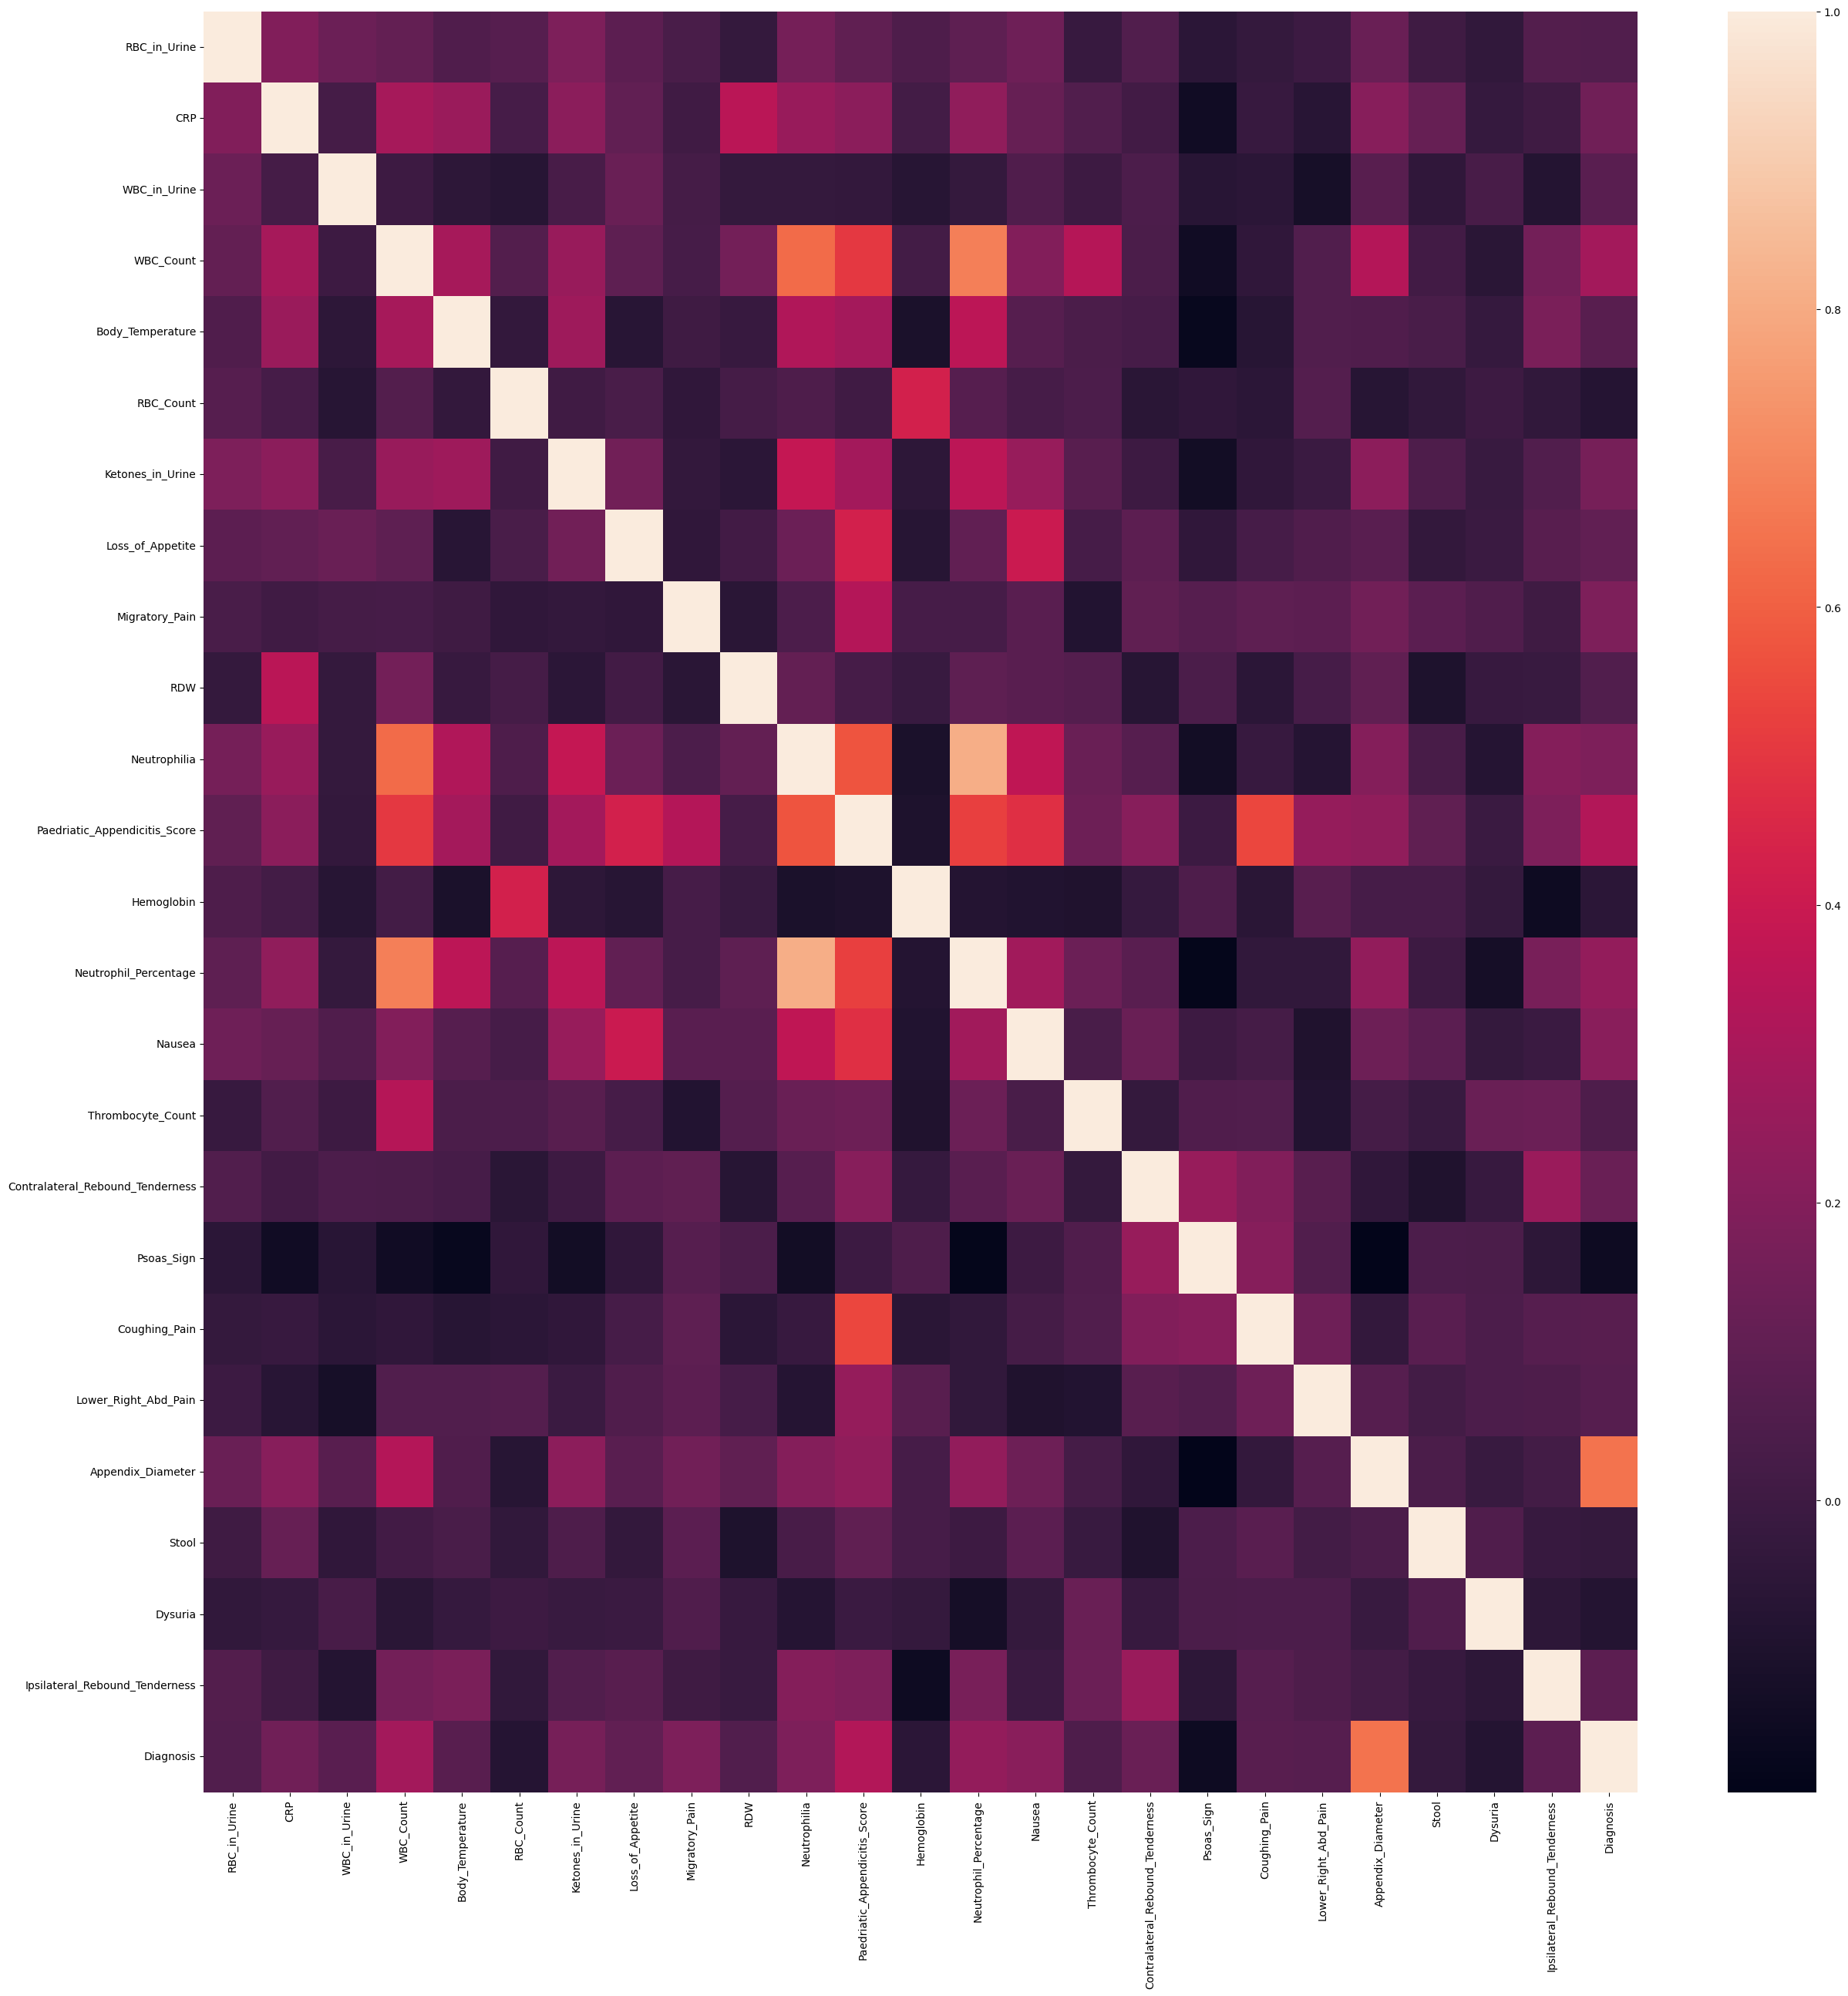

In [80]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)


# In[ ]:





# In[9]:


# correlation of different columns with each other
df.corr()


# # In[10]:


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# # In[11]:


# # list of columns with contains data of the ultrasound and have very few non na values
# US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
#               "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
#                "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]


# # In[12]:


# # since this is early diagnosing therfore assuming that the US is not performed
# # Hence removing all the columns that contains information of an ultrasound
# # df.drop(US_columns,axis=1,inplace=True)


# for v in col:
#     if v not in US_columns:
#         pass
#     else:
#         US_columns.remove('v')
# print(US_columns)

# df.drop(US_columns,axis=1,inplace=True)
# # In[13]:


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


df2["WBC_in_Urine"].value_counts()


# In[23]:


# df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


df.info()


# In[26]:


# df2["Sex"].value_counts()


# In[27]:


# df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


df.info()


# In[30]:


df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()


# In[36]:


df2["Nausea"].value_counts(dropna = False)


# In[37]:


df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()


# In[38]:


df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()


# In[40]:


df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()


# In[42]:


df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
# df2["Dysuria"].value_counts()


# In[51]:


# df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)


# In[53]:


# df2["Peritonitis"].value_counts()


# In[54]:


# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)


# In[55]:


# df2["Diagnosis"].corr(df2["Peritonitis"])


# In[56]:


#Adding a binary Peritonitis column since it has a better correlation with the target variable
# df2["Peritonitis_binary"] = (df2["Peritonitis"]!=0).astype(int)


# In[57]:


#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)


# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


# df2["Psoas_Sign"].value_counts()


# In[60]:


df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [81]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(247, 25)

In [82]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 247 entries, 0 to 780
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   RBC_in_Urine                      247 non-null    float64
 1   CRP                               247 non-null    float64
 2   WBC_in_Urine                      247 non-null    float64
 3   WBC_Count                         247 non-null    float64
 4   Body_Temperature                  247 non-null    float64
 5   RBC_Count                         247 non-null    float64
 6   Ketones_in_Urine                  247 non-null    float64
 7   Loss_of_Appetite                  247 non-null    int32  
 8   Migratory_Pain                    247 non-null    int32  
 9   RDW                               247 non-null    float64
 10  Neutrophilia                      247 non-null    int32  
 11  Paedriatic_Appendicitis_Score     247 non-null    float64
 12  Hemoglob

In [83]:
y.value_counts()

1    165
0     82
Name: Diagnosis, dtype: int64

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [86]:
x_train.shape

(197, 25)

In [87]:
# y_train.value_counts()

In [88]:
# col
x_train.columns

Index(['RBC_in_Urine', 'CRP', 'WBC_in_Urine', 'WBC_Count', 'Body_Temperature',
       'RBC_Count', 'Ketones_in_Urine', 'Loss_of_Appetite', 'Migratory_Pain',
       'RDW', 'Neutrophilia', 'Paedriatic_Appendicitis_Score', 'Hemoglobin',
       'Neutrophil_Percentage', 'Nausea', 'Thrombocyte_Count',
       'Contralateral_Rebound_Tenderness', 'Psoas_Sign', 'Coughing_Pain',
       'Lower_Right_Abd_Pain', 'Appendix_Diameter', 'Stool', 'Dysuria',
       'Free_Fluids', 'Ipsilateral_Rebound_Tenderness'],
      dtype='object')

In [89]:
y_test.value_counts()
y_train.value_counts()

1    128
0     69
Name: Diagnosis, dtype: int64

In [90]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.33      0.15      0.21        13
           1       0.75      0.89      0.81        37

    accuracy                           0.70        50
   macro avg       0.54      0.52      0.51        50
weighted avg       0.64      0.70      0.66        50



In [91]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.02 ± 0.00
TEST_ACCURACY - Mean: 0.69 ± 0.07
TEST_F1 - Mean: 0.78 ± 0.07
TEST_ROC_AUC - Mean: 0.62 ± 0.06
TEST_AVERAGE_PRECISION - Mean: 0.73 ± 0.10
TEST_PRECISION - Mean: 0.73 ± 0.11
TEST_RECALL - Mean: 0.86 ± 0.03


In [92]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7258 ± 0.10


In [93]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       1.00      0.70      0.83        37

    accuracy                           0.78        50
   macro avg       0.77      0.85      0.76        50
weighted avg       0.88      0.78      0.79        50



In [94]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.73 ± 0.08
TEST_F1 - Mean: 0.76 ± 0.11
TEST_ROC_AUC - Mean: 0.84 ± 0.12
TEST_AVERAGE_PRECISION - Mean: 0.89 ± 0.12
TEST_PRECISION - Mean: 0.86 ± 0.14
TEST_RECALL - Mean: 0.68 ± 0.09


In [95]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.8855 ± 0.12


In [96]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.74      1.00      0.85        37

    accuracy                           0.74        50
   macro avg       0.37      0.50      0.43        50
weighted avg       0.55      0.74      0.63        50



C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [97]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.67 ± 0.11
TEST_F1 - Mean: 0.80 ± 0.08
TEST_ROC_AUC - Mean: 0.79 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.90 ± 0.05
TEST_PRECISION - Mean: 0.67 ± 0.11
TEST_RECALL - Mean: 1.00 ± 0.00


In [98]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78        13
           1       0.90      0.97      0.94        37

    accuracy                           0.90        50
   macro avg       0.90      0.83      0.86        50
weighted avg       0.90      0.90      0.90        50



In [99]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.04
TEST_F1 - Mean: 0.94 ± 0.04
TEST_ROC_AUC - Mean: 0.92 ± 0.04
TEST_AVERAGE_PRECISION - Mean: 0.92 ± 0.05
TEST_PRECISION - Mean: 0.94 ± 0.04
TEST_RECALL - Mean: 0.95 ± 0.04


In [100]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9298 ± 0.04


In [101]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.97      0.95      0.96        38

    accuracy                           0.94        50
   macro avg       0.91      0.93      0.92        50
weighted avg       0.94      0.94      0.94        50



In [102]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v == 'score_time'):
         print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.1440 ± 0.02
SCORE_TIME - Mean: 0.0185 ± 0.01
TEST_ACCURACY - Mean: 0.96 ± 0.04
TEST_F1 - Mean: 0.97 ± 0.03
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [103]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9900 ± 0.01


In [104]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        13
           1       0.92      0.92      0.92        37

    accuracy                           0.88        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.88      0.88      0.88        50



In [105]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v == 'score_time'):
         print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.0316 ± 0.00
SCORE_TIME - Mean: 0.0164 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.04
TEST_F1 - Mean: 0.94 ± 0.03
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.94 ± 0.04
TEST_RECALL - Mean: 0.94 ± 0.03


In [106]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9915 ± 0.01


In [107]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        13
           1       1.00      0.95      0.97        37

    accuracy                           0.96        50
   macro avg       0.93      0.97      0.95        50
weighted avg       0.97      0.96      0.96        50



In [108]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v == 'score_time'):
         print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")
    

FIT_TIME - Mean: 0.0168 ± 0.00
SCORE_TIME - Mean: 0.0104 ± 0.00
TEST_ACCURACY - Mean: 0.96 ± 0.01
TEST_F1 - Mean: 0.97 ± 0.01
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.97 ± 0.03
TEST_RECALL - Mean: 0.96 ± 0.01


In [109]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9913 ± 0.01


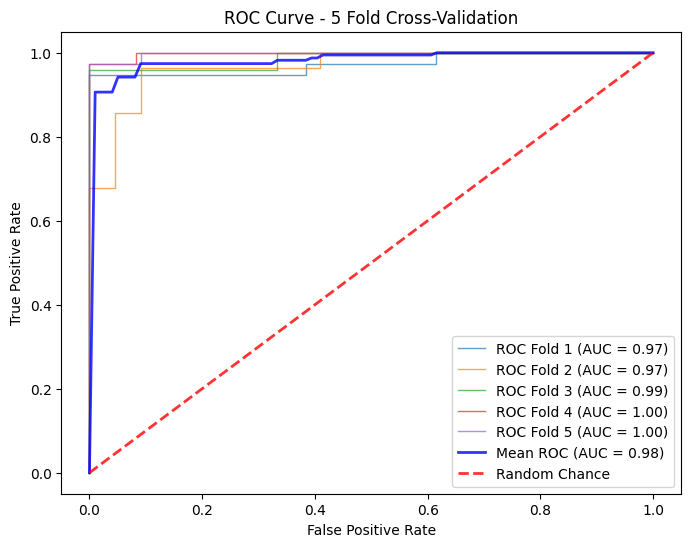

In [110]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [111]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.77      0.83        13
           1       0.92      0.97      0.95        37

    accuracy                           0.92        50
   macro avg       0.92      0.87      0.89        50
weighted avg       0.92      0.92      0.92        50



In [112]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v == 'score_time'):
         print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.0842 ± 0.01
SCORE_TIME - Mean: 0.0209 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.95 ± 0.02
TEST_RECALL - Mean: 0.97 ± 0.02


In [113]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9930 ± 0.01


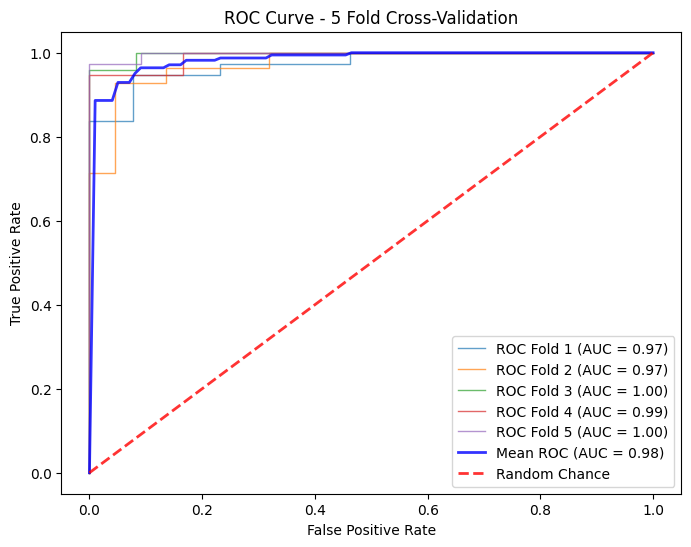

In [114]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [115]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        11
           1       0.97      0.92      0.95        39

    accuracy                           0.92        50
   macro avg       0.87      0.92      0.89        50
weighted avg       0.93      0.92      0.92        50



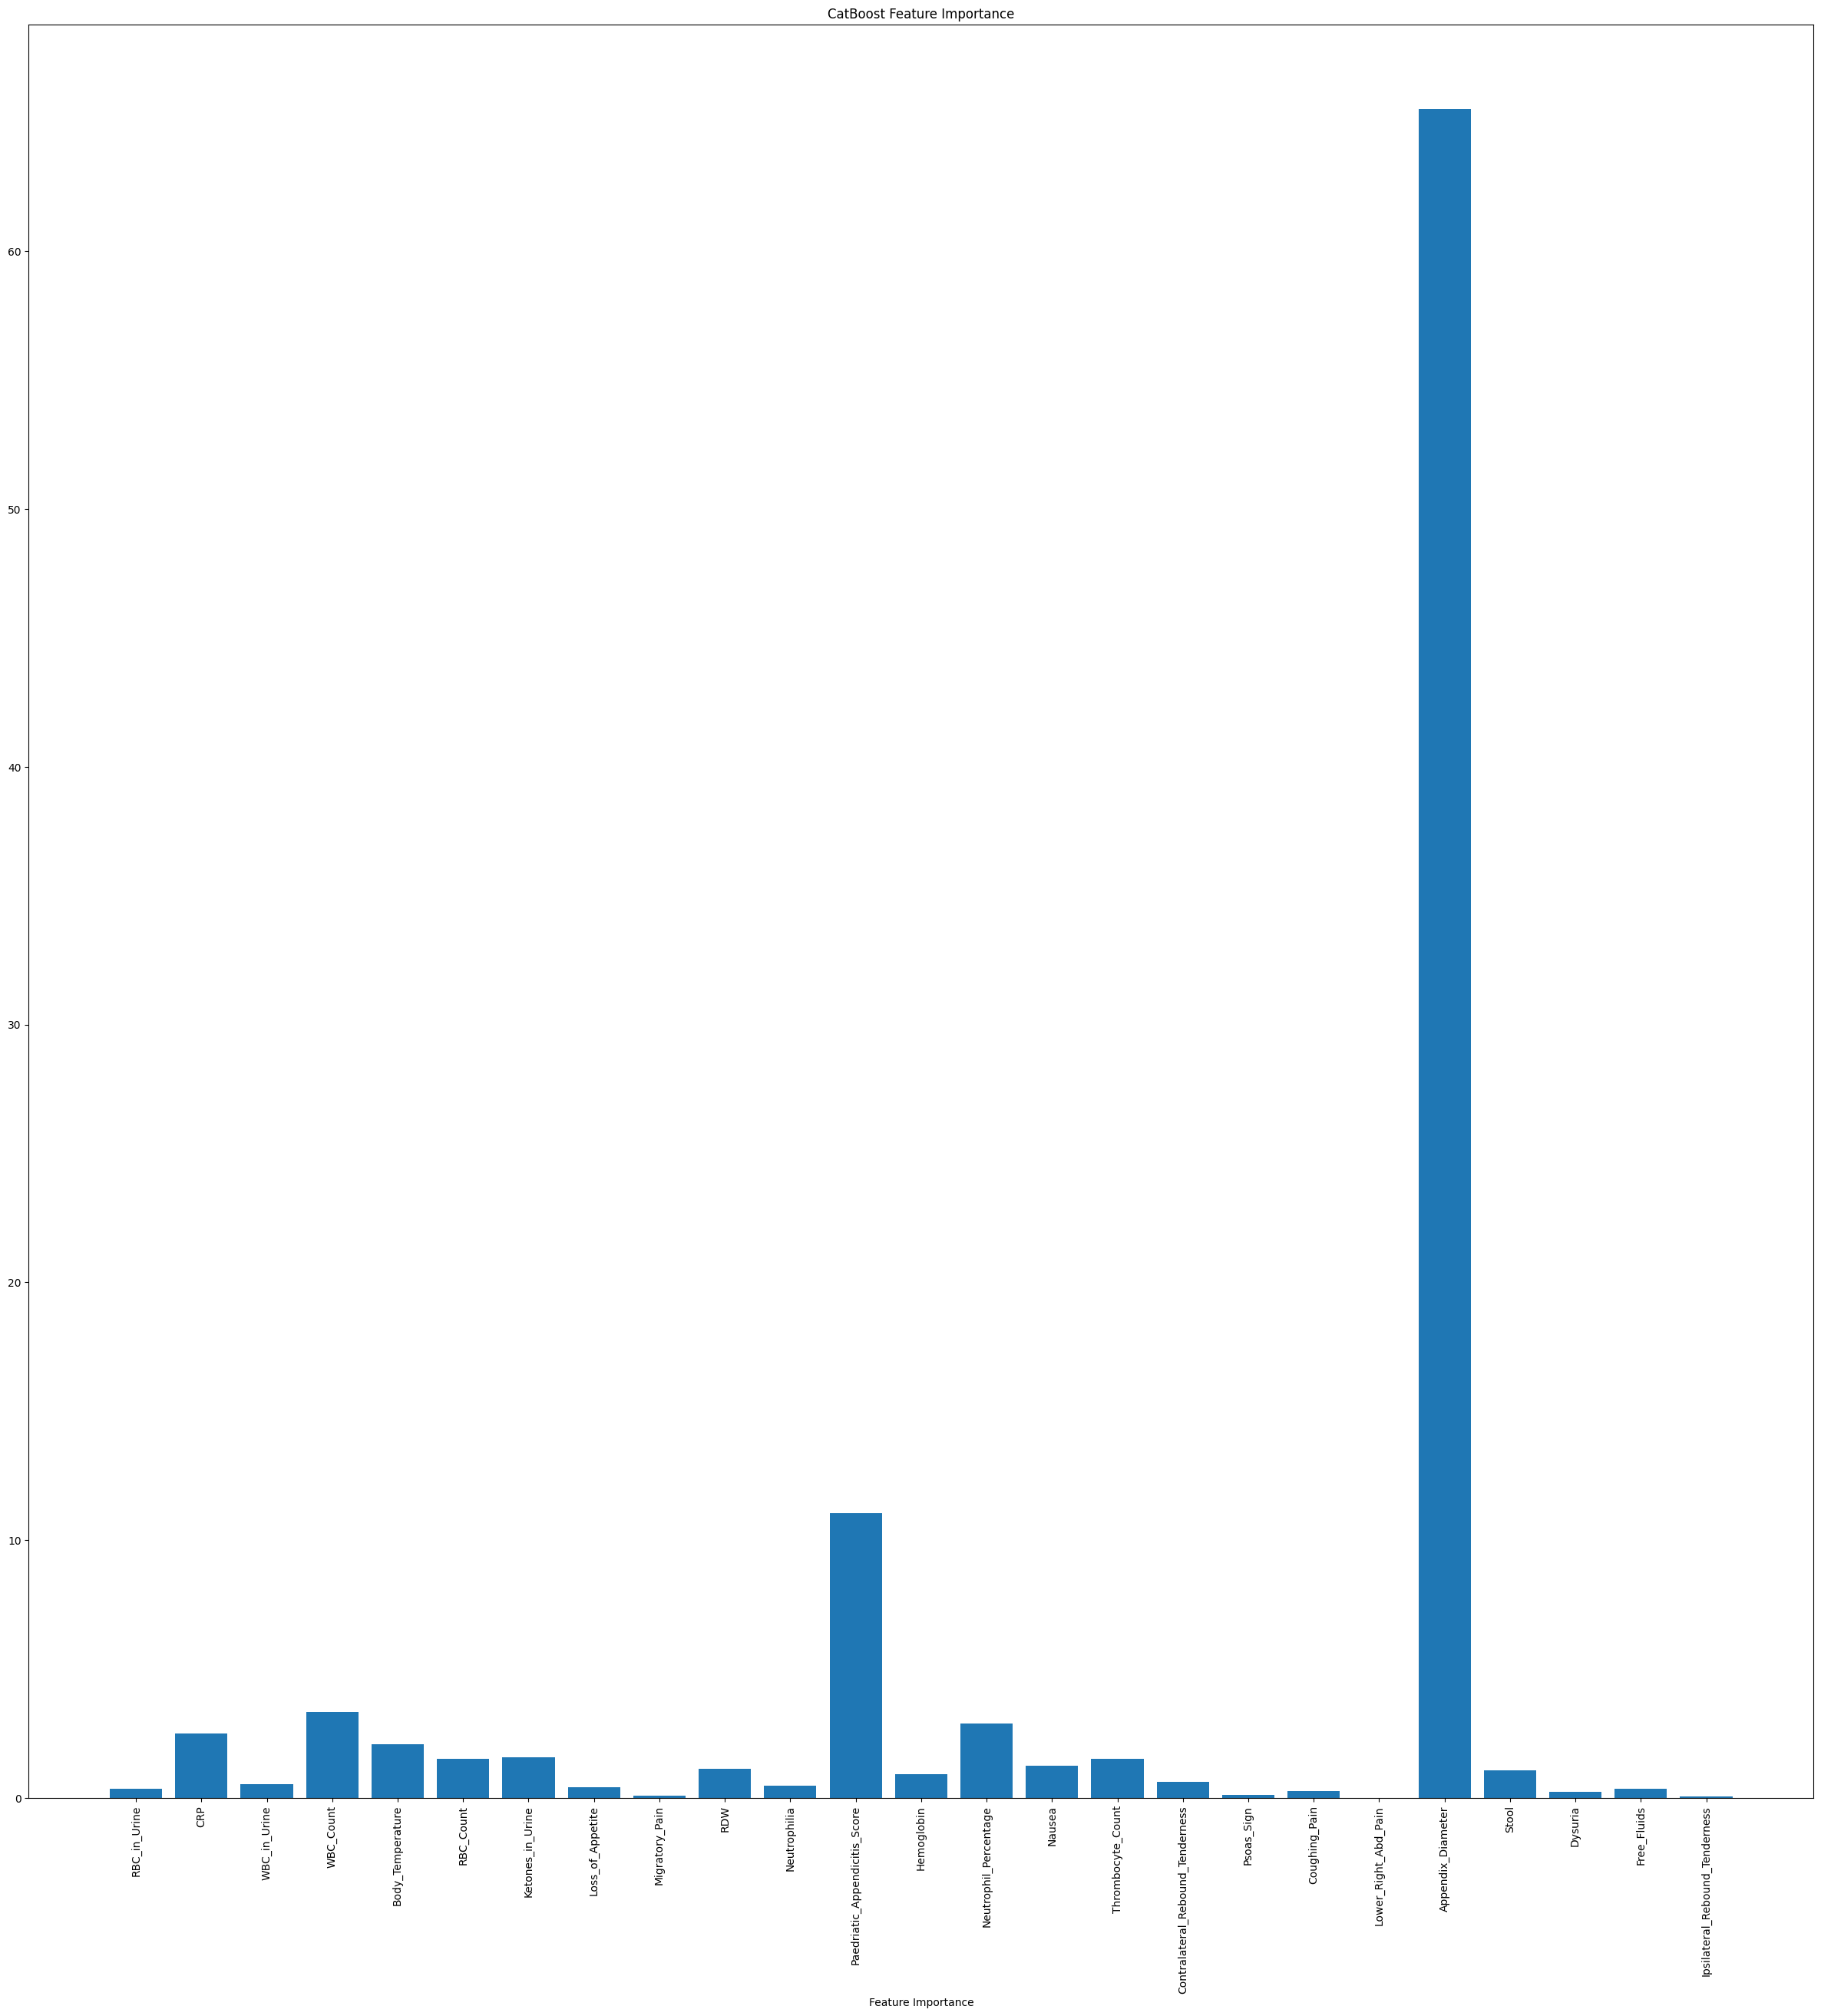

In [116]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = x_train.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [117]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate


X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v == 'score_time'):
         print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


0:	learn: 0.6809119	total: 2.26ms	remaining: 3.38s
1:	learn: 0.6695154	total: 4.92ms	remaining: 3.68s
2:	learn: 0.6551024	total: 6.71ms	remaining: 3.35s
3:	learn: 0.6428796	total: 8.81ms	remaining: 3.29s
4:	learn: 0.6314975	total: 10.8ms	remaining: 3.22s
5:	learn: 0.6207146	total: 13.4ms	remaining: 3.34s
6:	learn: 0.6107195	total: 15.2ms	remaining: 3.25s
7:	learn: 0.6023987	total: 16.8ms	remaining: 3.13s
8:	learn: 0.5942215	total: 18.4ms	remaining: 3.04s
9:	learn: 0.5842243	total: 19.9ms	remaining: 2.96s
10:	learn: 0.5736616	total: 21.4ms	remaining: 2.9s
11:	learn: 0.5619941	total: 23.2ms	remaining: 2.88s
12:	learn: 0.5532694	total: 24.7ms	remaining: 2.82s
13:	learn: 0.5474868	total: 26.2ms	remaining: 2.78s
14:	learn: 0.5399519	total: 27.6ms	remaining: 2.73s
15:	learn: 0.5326753	total: 29.3ms	remaining: 2.71s
16:	learn: 0.5244354	total: 30.8ms	remaining: 2.69s
17:	learn: 0.5152737	total: 32.4ms	remaining: 2.67s
18:	learn: 0.5088960	total: 33.8ms	remaining: 2.64s
19:	learn: 0.5010210	to

229:	learn: 0.0829647	total: 395ms	remaining: 2.18s
230:	learn: 0.0827720	total: 397ms	remaining: 2.18s
231:	learn: 0.0826898	total: 399ms	remaining: 2.18s
232:	learn: 0.0821925	total: 400ms	remaining: 2.17s
233:	learn: 0.0819925	total: 402ms	remaining: 2.17s
234:	learn: 0.0814961	total: 403ms	remaining: 2.17s
235:	learn: 0.0811923	total: 405ms	remaining: 2.17s
236:	learn: 0.0809440	total: 407ms	remaining: 2.17s
237:	learn: 0.0806380	total: 408ms	remaining: 2.17s
238:	learn: 0.0802639	total: 410ms	remaining: 2.16s
239:	learn: 0.0799520	total: 412ms	remaining: 2.16s
240:	learn: 0.0795070	total: 413ms	remaining: 2.16s
241:	learn: 0.0790293	total: 415ms	remaining: 2.16s
242:	learn: 0.0783096	total: 417ms	remaining: 2.16s
243:	learn: 0.0779416	total: 419ms	remaining: 2.16s
244:	learn: 0.0775882	total: 421ms	remaining: 2.16s
245:	learn: 0.0773637	total: 423ms	remaining: 2.15s
246:	learn: 0.0772214	total: 424ms	remaining: 2.15s
247:	learn: 0.0765968	total: 426ms	remaining: 2.15s
248:	learn: 

464:	learn: 0.0372151	total: 777ms	remaining: 1.73s
465:	learn: 0.0371262	total: 780ms	remaining: 1.73s
466:	learn: 0.0369202	total: 782ms	remaining: 1.73s
467:	learn: 0.0366549	total: 784ms	remaining: 1.73s
468:	learn: 0.0365128	total: 786ms	remaining: 1.73s
469:	learn: 0.0362556	total: 788ms	remaining: 1.73s
470:	learn: 0.0360456	total: 790ms	remaining: 1.73s
471:	learn: 0.0360127	total: 792ms	remaining: 1.73s
472:	learn: 0.0359430	total: 795ms	remaining: 1.73s
473:	learn: 0.0359243	total: 797ms	remaining: 1.73s
474:	learn: 0.0358762	total: 800ms	remaining: 1.73s
475:	learn: 0.0358441	total: 802ms	remaining: 1.72s
476:	learn: 0.0357806	total: 804ms	remaining: 1.72s
477:	learn: 0.0357568	total: 806ms	remaining: 1.72s
478:	learn: 0.0356880	total: 808ms	remaining: 1.72s
479:	learn: 0.0355986	total: 810ms	remaining: 1.72s
480:	learn: 0.0354012	total: 812ms	remaining: 1.72s
481:	learn: 0.0353397	total: 813ms	remaining: 1.72s
482:	learn: 0.0353220	total: 815ms	remaining: 1.72s
483:	learn: 

709:	learn: 0.0189671	total: 1.17s	remaining: 1.31s
710:	learn: 0.0188867	total: 1.18s	remaining: 1.3s
711:	learn: 0.0187998	total: 1.18s	remaining: 1.3s
712:	learn: 0.0187887	total: 1.18s	remaining: 1.3s
713:	learn: 0.0187675	total: 1.18s	remaining: 1.3s
714:	learn: 0.0187549	total: 1.18s	remaining: 1.3s
715:	learn: 0.0187478	total: 1.18s	remaining: 1.3s
716:	learn: 0.0187311	total: 1.19s	remaining: 1.29s
717:	learn: 0.0186461	total: 1.19s	remaining: 1.29s
718:	learn: 0.0186355	total: 1.19s	remaining: 1.29s
719:	learn: 0.0185525	total: 1.19s	remaining: 1.29s
720:	learn: 0.0185469	total: 1.19s	remaining: 1.29s
721:	learn: 0.0185374	total: 1.2s	remaining: 1.29s
722:	learn: 0.0185304	total: 1.2s	remaining: 1.29s
723:	learn: 0.0184548	total: 1.2s	remaining: 1.28s
724:	learn: 0.0183678	total: 1.2s	remaining: 1.28s
725:	learn: 0.0182780	total: 1.2s	remaining: 1.28s
726:	learn: 0.0182604	total: 1.2s	remaining: 1.28s
727:	learn: 0.0181942	total: 1.2s	remaining: 1.28s
728:	learn: 0.0181851	tot

949:	learn: 0.0124334	total: 1.55s	remaining: 900ms
950:	learn: 0.0124298	total: 1.55s	remaining: 898ms
951:	learn: 0.0124234	total: 1.56s	remaining: 896ms
952:	learn: 0.0123847	total: 1.56s	remaining: 894ms
953:	learn: 0.0123754	total: 1.56s	remaining: 893ms
954:	learn: 0.0123679	total: 1.56s	remaining: 891ms
955:	learn: 0.0123568	total: 1.56s	remaining: 889ms
956:	learn: 0.0123461	total: 1.56s	remaining: 888ms
957:	learn: 0.0123432	total: 1.57s	remaining: 886ms
958:	learn: 0.0123136	total: 1.57s	remaining: 885ms
959:	learn: 0.0122770	total: 1.57s	remaining: 883ms
960:	learn: 0.0122725	total: 1.57s	remaining: 881ms
961:	learn: 0.0122435	total: 1.57s	remaining: 880ms
962:	learn: 0.0121999	total: 1.57s	remaining: 878ms
963:	learn: 0.0121905	total: 1.58s	remaining: 877ms
964:	learn: 0.0121792	total: 1.58s	remaining: 875ms
965:	learn: 0.0121678	total: 1.58s	remaining: 873ms
966:	learn: 0.0121399	total: 1.58s	remaining: 871ms
967:	learn: 0.0121238	total: 1.58s	remaining: 870ms
968:	learn: 

...

459:	learn: 0.0441441	total: 839ms	remaining: 1.9s
460:	learn: 0.0440846	total: 841ms	remaining: 1.89s
461:	learn: 0.0440131	total: 842ms	remaining: 1.89s
462:	learn: 0.0437862	total: 844ms	remaining: 1.89s
463:	learn: 0.0435819	total: 846ms	remaining: 1.89s
464:	learn: 0.0433951	total: 847ms	remaining: 1.89s
465:	learn: 0.0432737	total: 849ms	remaining: 1.88s
466:	learn: 0.0430553	total: 851ms	remaining: 1.88s
467:	learn: 0.0428957	total: 853ms	remaining: 1.88s
468:	learn: 0.0426878	total: 855ms	remaining: 1.88s
469:	learn: 0.0425577	total: 857ms	remaining: 1.88s
470:	learn: 0.0424327	total: 859ms	remaining: 1.88s
471:	learn: 0.0422622	total: 861ms	remaining: 1.88s
472:	learn: 0.0421749	total: 863ms	remaining: 1.87s
473:	learn: 0.0421107	total: 884ms	remaining: 1.91s
474:	learn: 0.0418919	total: 886ms	remaining: 1.91s
475:	learn: 0.0417042	total: 888ms	remaining: 1.91s
476:	learn: 0.0415570	total: 890ms	remaining: 1.91s
477:	learn: 0.0413690	total: 891ms	remaining: 1.91s
478:	learn: 0

674:	learn: 0.0236514	total: 1.24s	remaining: 1.51s
675:	learn: 0.0236028	total: 1.24s	remaining: 1.51s
676:	learn: 0.0234745	total: 1.24s	remaining: 1.51s
677:	learn: 0.0234597	total: 1.24s	remaining: 1.5s
678:	learn: 0.0233925	total: 1.24s	remaining: 1.5s
679:	learn: 0.0233459	total: 1.24s	remaining: 1.5s
680:	learn: 0.0233305	total: 1.25s	remaining: 1.5s
681:	learn: 0.0232777	total: 1.25s	remaining: 1.5s
682:	learn: 0.0232539	total: 1.25s	remaining: 1.5s
683:	learn: 0.0231908	total: 1.25s	remaining: 1.49s
684:	learn: 0.0231456	total: 1.25s	remaining: 1.49s
685:	learn: 0.0231130	total: 1.25s	remaining: 1.49s
686:	learn: 0.0230360	total: 1.26s	remaining: 1.49s
687:	learn: 0.0229594	total: 1.26s	remaining: 1.49s
688:	learn: 0.0229358	total: 1.26s	remaining: 1.48s
689:	learn: 0.0228589	total: 1.26s	remaining: 1.48s
690:	learn: 0.0227822	total: 1.26s	remaining: 1.48s
691:	learn: 0.0227035	total: 1.26s	remaining: 1.48s
692:	learn: 0.0226402	total: 1.27s	remaining: 1.47s
693:	learn: 0.0226

898:	learn: 0.0140770	total: 1.62s	remaining: 1.08s
899:	learn: 0.0140508	total: 1.62s	remaining: 1.08s
900:	learn: 0.0140455	total: 1.62s	remaining: 1.08s
901:	learn: 0.0140252	total: 1.62s	remaining: 1.07s
902:	learn: 0.0139904	total: 1.62s	remaining: 1.07s
903:	learn: 0.0139849	total: 1.63s	remaining: 1.07s
904:	learn: 0.0139609	total: 1.63s	remaining: 1.07s
905:	learn: 0.0139374	total: 1.63s	remaining: 1.07s
906:	learn: 0.0139033	total: 1.63s	remaining: 1.07s
907:	learn: 0.0138786	total: 1.63s	remaining: 1.06s
908:	learn: 0.0138228	total: 1.63s	remaining: 1.06s
909:	learn: 0.0137819	total: 1.64s	remaining: 1.06s
910:	learn: 0.0137770	total: 1.64s	remaining: 1.06s
911:	learn: 0.0137434	total: 1.64s	remaining: 1.06s
912:	learn: 0.0137331	total: 1.64s	remaining: 1.05s
913:	learn: 0.0137080	total: 1.64s	remaining: 1.05s
914:	learn: 0.0137037	total: 1.65s	remaining: 1.05s
915:	learn: 0.0136929	total: 1.65s	remaining: 1.05s
916:	learn: 0.0136599	total: 1.65s	remaining: 1.05s
917:	learn: 

1117:	learn: 0.0100678	total: 2.02s	remaining: 691ms
1118:	learn: 0.0100333	total: 2.02s	remaining: 689ms
1119:	learn: 0.0100115	total: 2.02s	remaining: 687ms
1120:	learn: 0.0099901	total: 2.03s	remaining: 686ms
1121:	learn: 0.0099880	total: 2.03s	remaining: 684ms
1122:	learn: 0.0099690	total: 2.03s	remaining: 682ms
1123:	learn: 0.0099480	total: 2.03s	remaining: 680ms
1124:	learn: 0.0099421	total: 2.04s	remaining: 678ms
1125:	learn: 0.0099405	total: 2.04s	remaining: 677ms
1126:	learn: 0.0099178	total: 2.04s	remaining: 675ms
1127:	learn: 0.0099045	total: 2.04s	remaining: 674ms
1128:	learn: 0.0099014	total: 2.04s	remaining: 672ms
1129:	learn: 0.0098987	total: 2.05s	remaining: 670ms
1130:	learn: 0.0098802	total: 2.05s	remaining: 668ms
1131:	learn: 0.0098782	total: 2.05s	remaining: 666ms
1132:	learn: 0.0098725	total: 2.05s	remaining: 665ms
1133:	learn: 0.0098700	total: 2.05s	remaining: 663ms
1134:	learn: 0.0098583	total: 2.05s	remaining: 661ms
1135:	learn: 0.0098416	total: 2.06s	remaining:

1341:	learn: 0.0078710	total: 2.41s	remaining: 284ms
1342:	learn: 0.0078661	total: 2.41s	remaining: 282ms
1343:	learn: 0.0078541	total: 2.41s	remaining: 280ms
1344:	learn: 0.0078401	total: 2.42s	remaining: 278ms
1345:	learn: 0.0078255	total: 2.42s	remaining: 277ms
1346:	learn: 0.0078135	total: 2.42s	remaining: 275ms
1347:	learn: 0.0078100	total: 2.42s	remaining: 273ms
1348:	learn: 0.0078014	total: 2.42s	remaining: 271ms
1349:	learn: 0.0077907	total: 2.43s	remaining: 270ms
1350:	learn: 0.0077779	total: 2.43s	remaining: 268ms
1351:	learn: 0.0077678	total: 2.43s	remaining: 266ms
1352:	learn: 0.0077522	total: 2.43s	remaining: 264ms
1353:	learn: 0.0077431	total: 2.43s	remaining: 263ms
1354:	learn: 0.0077303	total: 2.44s	remaining: 261ms
1355:	learn: 0.0077203	total: 2.44s	remaining: 259ms
1356:	learn: 0.0077190	total: 2.44s	remaining: 257ms
1357:	learn: 0.0077168	total: 2.44s	remaining: 255ms
1358:	learn: 0.0077119	total: 2.44s	remaining: 253ms
1359:	learn: 0.0077095	total: 2.44s	remaining:

In [118]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

0:	learn: 0.6809119	total: 3.68ms	remaining: 5.51s
1:	learn: 0.6695154	total: 7.3ms	remaining: 5.47s
2:	learn: 0.6551024	total: 9.08ms	remaining: 4.53s
3:	learn: 0.6428796	total: 10.7ms	remaining: 4s
4:	learn: 0.6314975	total: 12.1ms	remaining: 3.63s
5:	learn: 0.6207146	total: 13.7ms	remaining: 3.4s
6:	learn: 0.6107195	total: 15.1ms	remaining: 3.23s
7:	learn: 0.6023987	total: 16.8ms	remaining: 3.13s
8:	learn: 0.5942215	total: 18.4ms	remaining: 3.06s
9:	learn: 0.5842243	total: 20ms	remaining: 2.98s
10:	learn: 0.5736616	total: 22.8ms	remaining: 3.09s
11:	learn: 0.5619941	total: 24.7ms	remaining: 3.06s
12:	learn: 0.5532694	total: 26.6ms	remaining: 3.04s
13:	learn: 0.5474868	total: 28.4ms	remaining: 3.01s
14:	learn: 0.5399519	total: 30.2ms	remaining: 2.99s
15:	learn: 0.5326753	total: 31.9ms	remaining: 2.96s
16:	learn: 0.5244354	total: 33.5ms	remaining: 2.92s
17:	learn: 0.5152737	total: 35.3ms	remaining: 2.91s
18:	learn: 0.5088960	total: 36.9ms	remaining: 2.88s
19:	learn: 0.5010210	total: 3

206:	learn: 0.0941804	total: 395ms	remaining: 2.46s
207:	learn: 0.0933819	total: 397ms	remaining: 2.46s
208:	learn: 0.0927297	total: 398ms	remaining: 2.46s
209:	learn: 0.0923364	total: 400ms	remaining: 2.46s
210:	learn: 0.0921588	total: 402ms	remaining: 2.46s
211:	learn: 0.0919559	total: 405ms	remaining: 2.46s
212:	learn: 0.0917689	total: 406ms	remaining: 2.45s
213:	learn: 0.0912582	total: 408ms	remaining: 2.45s
214:	learn: 0.0905252	total: 410ms	remaining: 2.45s
215:	learn: 0.0898782	total: 412ms	remaining: 2.45s
216:	learn: 0.0893585	total: 414ms	remaining: 2.45s
217:	learn: 0.0886301	total: 416ms	remaining: 2.44s
218:	learn: 0.0881174	total: 417ms	remaining: 2.44s
219:	learn: 0.0875391	total: 419ms	remaining: 2.44s
220:	learn: 0.0868728	total: 421ms	remaining: 2.44s
221:	learn: 0.0862394	total: 424ms	remaining: 2.44s
222:	learn: 0.0861113	total: 425ms	remaining: 2.44s
223:	learn: 0.0857997	total: 427ms	remaining: 2.43s
224:	learn: 0.0853963	total: 429ms	remaining: 2.43s
225:	learn: 

438:	learn: 0.0398374	total: 779ms	remaining: 1.88s
439:	learn: 0.0397087	total: 782ms	remaining: 1.88s
440:	learn: 0.0396176	total: 783ms	remaining: 1.88s
441:	learn: 0.0394539	total: 785ms	remaining: 1.88s
442:	learn: 0.0393127	total: 787ms	remaining: 1.88s
443:	learn: 0.0390958	total: 790ms	remaining: 1.88s
444:	learn: 0.0389819	total: 792ms	remaining: 1.88s
445:	learn: 0.0389287	total: 793ms	remaining: 1.87s
446:	learn: 0.0388435	total: 795ms	remaining: 1.87s
447:	learn: 0.0388033	total: 798ms	remaining: 1.87s
448:	learn: 0.0387571	total: 799ms	remaining: 1.87s
449:	learn: 0.0385797	total: 802ms	remaining: 1.87s
450:	learn: 0.0384995	total: 804ms	remaining: 1.87s
451:	learn: 0.0384483	total: 806ms	remaining: 1.87s
452:	learn: 0.0384011	total: 808ms	remaining: 1.87s
453:	learn: 0.0383618	total: 810ms	remaining: 1.86s
454:	learn: 0.0381920	total: 812ms	remaining: 1.86s
455:	learn: 0.0379703	total: 814ms	remaining: 1.86s
456:	learn: 0.0379168	total: 816ms	remaining: 1.86s
457:	learn: 

625:	learn: 0.0234370	total: 1.15s	remaining: 1.61s
626:	learn: 0.0234161	total: 1.15s	remaining: 1.6s
627:	learn: 0.0233888	total: 1.16s	remaining: 1.6s
628:	learn: 0.0233688	total: 1.16s	remaining: 1.6s
629:	learn: 0.0232585	total: 1.16s	remaining: 1.6s
630:	learn: 0.0231495	total: 1.16s	remaining: 1.6s
631:	learn: 0.0230214	total: 1.16s	remaining: 1.6s
632:	learn: 0.0230006	total: 1.16s	remaining: 1.59s
633:	learn: 0.0229759	total: 1.17s	remaining: 1.59s
634:	learn: 0.0228746	total: 1.17s	remaining: 1.59s
635:	learn: 0.0228568	total: 1.17s	remaining: 1.59s
636:	learn: 0.0228434	total: 1.17s	remaining: 1.59s
637:	learn: 0.0227300	total: 1.17s	remaining: 1.58s
638:	learn: 0.0226214	total: 1.17s	remaining: 1.58s
639:	learn: 0.0226040	total: 1.18s	remaining: 1.58s
640:	learn: 0.0225141	total: 1.18s	remaining: 1.58s
641:	learn: 0.0223970	total: 1.18s	remaining: 1.58s
642:	learn: 0.0222509	total: 1.18s	remaining: 1.57s
643:	learn: 0.0222214	total: 1.18s	remaining: 1.57s
644:	learn: 0.0222

868:	learn: 0.0143589	total: 1.55s	remaining: 1.12s
869:	learn: 0.0143461	total: 1.55s	remaining: 1.12s
870:	learn: 0.0143312	total: 1.55s	remaining: 1.12s
871:	learn: 0.0143080	total: 1.55s	remaining: 1.12s
872:	learn: 0.0142953	total: 1.55s	remaining: 1.11s
873:	learn: 0.0142388	total: 1.55s	remaining: 1.11s
874:	learn: 0.0142321	total: 1.56s	remaining: 1.11s
875:	learn: 0.0141791	total: 1.56s	remaining: 1.11s
876:	learn: 0.0141682	total: 1.56s	remaining: 1.11s
877:	learn: 0.0141312	total: 1.56s	remaining: 1.11s
878:	learn: 0.0140920	total: 1.56s	remaining: 1.1s
879:	learn: 0.0140865	total: 1.56s	remaining: 1.1s
880:	learn: 0.0140724	total: 1.57s	remaining: 1.1s
881:	learn: 0.0140170	total: 1.57s	remaining: 1.1s
882:	learn: 0.0139683	total: 1.57s	remaining: 1.1s
883:	learn: 0.0139577	total: 1.57s	remaining: 1.09s
884:	learn: 0.0139402	total: 1.57s	remaining: 1.09s
885:	learn: 0.0139286	total: 1.57s	remaining: 1.09s
886:	learn: 0.0139017	total: 1.58s	remaining: 1.09s
887:	learn: 0.013

...

664:	learn: 0.0242019	total: 1.18s	remaining: 1.49s
665:	learn: 0.0240664	total: 1.19s	remaining: 1.49s
666:	learn: 0.0240559	total: 1.19s	remaining: 1.48s
667:	learn: 0.0239846	total: 1.19s	remaining: 1.48s
668:	learn: 0.0239743	total: 1.19s	remaining: 1.48s
669:	learn: 0.0239293	total: 1.2s	remaining: 1.48s
670:	learn: 0.0238210	total: 1.2s	remaining: 1.48s
671:	learn: 0.0238166	total: 1.2s	remaining: 1.48s
672:	learn: 0.0237910	total: 1.2s	remaining: 1.48s
673:	learn: 0.0237115	total: 1.21s	remaining: 1.48s
674:	learn: 0.0236514	total: 1.21s	remaining: 1.48s
675:	learn: 0.0236028	total: 1.21s	remaining: 1.47s
676:	learn: 0.0234745	total: 1.21s	remaining: 1.47s
677:	learn: 0.0234597	total: 1.21s	remaining: 1.47s
678:	learn: 0.0233925	total: 1.21s	remaining: 1.47s
679:	learn: 0.0233459	total: 1.22s	remaining: 1.47s
680:	learn: 0.0233305	total: 1.22s	remaining: 1.46s
681:	learn: 0.0232777	total: 1.22s	remaining: 1.46s
682:	learn: 0.0232539	total: 1.22s	remaining: 1.46s
683:	learn: 0.02

847:	learn: 0.0155551	total: 1.58s	remaining: 1.22s
848:	learn: 0.0155185	total: 1.58s	remaining: 1.21s
849:	learn: 0.0154870	total: 1.59s	remaining: 1.21s
850:	learn: 0.0154812	total: 1.59s	remaining: 1.21s
851:	learn: 0.0154490	total: 1.59s	remaining: 1.21s
852:	learn: 0.0154068	total: 1.59s	remaining: 1.21s
853:	learn: 0.0153785	total: 1.6s	remaining: 1.21s
854:	learn: 0.0153375	total: 1.6s	remaining: 1.21s
855:	learn: 0.0153335	total: 1.6s	remaining: 1.21s
856:	learn: 0.0153046	total: 1.6s	remaining: 1.2s
857:	learn: 0.0152557	total: 1.61s	remaining: 1.2s
858:	learn: 0.0151919	total: 1.61s	remaining: 1.2s
859:	learn: 0.0151611	total: 1.61s	remaining: 1.2s
860:	learn: 0.0151579	total: 1.61s	remaining: 1.2s
861:	learn: 0.0150950	total: 1.61s	remaining: 1.2s
862:	learn: 0.0150561	total: 1.62s	remaining: 1.19s
863:	learn: 0.0150260	total: 1.62s	remaining: 1.19s
864:	learn: 0.0150221	total: 1.62s	remaining: 1.19s
865:	learn: 0.0150156	total: 1.62s	remaining: 1.19s
866:	learn: 0.0149743	

1029:	learn: 0.0112751	total: 1.96s	remaining: 895ms
1030:	learn: 0.0112483	total: 1.96s	remaining: 893ms
1031:	learn: 0.0112310	total: 1.97s	remaining: 892ms
1032:	learn: 0.0112121	total: 1.97s	remaining: 890ms
1033:	learn: 0.0112104	total: 1.97s	remaining: 889ms
1034:	learn: 0.0111842	total: 1.97s	remaining: 887ms
1035:	learn: 0.0111711	total: 1.98s	remaining: 885ms
1036:	learn: 0.0111539	total: 1.98s	remaining: 883ms
1037:	learn: 0.0111508	total: 1.98s	remaining: 882ms
1038:	learn: 0.0111251	total: 1.98s	remaining: 881ms
1039:	learn: 0.0111092	total: 1.99s	remaining: 879ms
1040:	learn: 0.0110996	total: 1.99s	remaining: 876ms
1041:	learn: 0.0110893	total: 1.99s	remaining: 875ms
1042:	learn: 0.0110865	total: 1.99s	remaining: 873ms
1043:	learn: 0.0110825	total: 1.99s	remaining: 871ms
1044:	learn: 0.0110664	total: 2s	remaining: 869ms
1045:	learn: 0.0110436	total: 2s	remaining: 867ms
1046:	learn: 0.0110270	total: 2s	remaining: 865ms
1047:	learn: 0.0110091	total: 2s	remaining: 863ms
1048:

1267:	learn: 0.0084656	total: 2.53s	remaining: 463ms
1268:	learn: 0.0084498	total: 2.54s	remaining: 462ms
1269:	learn: 0.0084388	total: 2.54s	remaining: 460ms
1270:	learn: 0.0084332	total: 2.54s	remaining: 458ms
1271:	learn: 0.0084310	total: 2.54s	remaining: 456ms
1272:	learn: 0.0084143	total: 2.54s	remaining: 454ms
1273:	learn: 0.0083987	total: 2.55s	remaining: 452ms
1274:	learn: 0.0083830	total: 2.55s	remaining: 450ms
1275:	learn: 0.0083773	total: 2.55s	remaining: 449ms
1276:	learn: 0.0083759	total: 2.56s	remaining: 446ms
1277:	learn: 0.0083759	total: 2.56s	remaining: 444ms
1278:	learn: 0.0083732	total: 2.56s	remaining: 442ms
1279:	learn: 0.0083613	total: 2.56s	remaining: 440ms
1280:	learn: 0.0083531	total: 2.56s	remaining: 438ms
1281:	learn: 0.0083477	total: 2.56s	remaining: 436ms
1282:	learn: 0.0083420	total: 2.57s	remaining: 434ms
1283:	learn: 0.0083286	total: 2.57s	remaining: 432ms
1284:	learn: 0.0083189	total: 2.57s	remaining: 430ms
1285:	learn: 0.0083183	total: 2.57s	remaining:

1479:	learn: 0.0067652	total: 2.92s	remaining: 39.5ms
1480:	learn: 0.0067559	total: 2.92s	remaining: 37.5ms
1481:	learn: 0.0067550	total: 2.92s	remaining: 35.5ms
1482:	learn: 0.0067539	total: 2.93s	remaining: 33.5ms
1483:	learn: 0.0067447	total: 2.93s	remaining: 31.6ms
1484:	learn: 0.0067342	total: 2.93s	remaining: 29.6ms
1485:	learn: 0.0067251	total: 2.93s	remaining: 27.6ms
1486:	learn: 0.0067236	total: 2.94s	remaining: 25.7ms
1487:	learn: 0.0067161	total: 2.94s	remaining: 23.7ms
1488:	learn: 0.0067077	total: 2.94s	remaining: 21.7ms
1489:	learn: 0.0067065	total: 2.94s	remaining: 19.8ms
1490:	learn: 0.0066976	total: 2.94s	remaining: 17.8ms
1491:	learn: 0.0066902	total: 2.95s	remaining: 15.8ms
1492:	learn: 0.0066817	total: 2.95s	remaining: 13.8ms
1493:	learn: 0.0066764	total: 2.95s	remaining: 11.8ms
1494:	learn: 0.0066676	total: 2.95s	remaining: 9.87ms
1495:	learn: 0.0066616	total: 2.95s	remaining: 7.9ms
1496:	learn: 0.0066598	total: 2.95s	remaining: 5.92ms
1497:	learn: 0.0066532	total:

0:	learn: 0.6809119	total: 3.98ms	remaining: 5.97s
1:	learn: 0.6695154	total: 8.82ms	remaining: 6.61s
2:	learn: 0.6551024	total: 12.5ms	remaining: 6.24s
3:	learn: 0.6428796	total: 15.7ms	remaining: 5.89s
4:	learn: 0.6314975	total: 19.9ms	remaining: 5.95s
5:	learn: 0.6207146	total: 23.3ms	remaining: 5.79s
6:	learn: 0.6107195	total: 26.2ms	remaining: 5.58s
7:	learn: 0.6023987	total: 28.9ms	remaining: 5.39s
8:	learn: 0.5942215	total: 30.7ms	remaining: 5.08s
9:	learn: 0.5842243	total: 32.1ms	remaining: 4.78s
10:	learn: 0.5736616	total: 34ms	remaining: 4.61s
11:	learn: 0.5619941	total: 36.3ms	remaining: 4.5s
12:	learn: 0.5532694	total: 38ms	remaining: 4.34s
13:	learn: 0.5474868	total: 39.6ms	remaining: 4.2s
14:	learn: 0.5399519	total: 41.1ms	remaining: 4.06s
15:	learn: 0.5326753	total: 43ms	remaining: 3.98s
16:	learn: 0.5244354	total: 44.9ms	remaining: 3.92s
17:	learn: 0.5152737	total: 46.7ms	remaining: 3.84s
18:	learn: 0.5088960	total: 48ms	remaining: 3.74s
19:	learn: 0.5010210	total: 49.7

180:	learn: 0.1048277	total: 392ms	remaining: 2.86s
181:	learn: 0.1042429	total: 395ms	remaining: 2.86s
182:	learn: 0.1038774	total: 397ms	remaining: 2.86s
183:	learn: 0.1031246	total: 400ms	remaining: 2.86s
184:	learn: 0.1027215	total: 404ms	remaining: 2.87s
185:	learn: 0.1021231	total: 406ms	remaining: 2.87s
186:	learn: 0.1017970	total: 409ms	remaining: 2.87s
187:	learn: 0.1014674	total: 411ms	remaining: 2.87s
188:	learn: 0.1011699	total: 414ms	remaining: 2.87s
189:	learn: 0.1007545	total: 417ms	remaining: 2.87s
190:	learn: 0.1001614	total: 419ms	remaining: 2.87s
191:	learn: 0.0995470	total: 421ms	remaining: 2.87s
192:	learn: 0.0992501	total: 423ms	remaining: 2.87s
193:	learn: 0.0991633	total: 425ms	remaining: 2.86s
194:	learn: 0.0989721	total: 428ms	remaining: 2.87s
195:	learn: 0.0984137	total: 431ms	remaining: 2.87s
196:	learn: 0.0983123	total: 434ms	remaining: 2.87s
197:	learn: 0.0978274	total: 437ms	remaining: 2.87s
198:	learn: 0.0977696	total: 438ms	remaining: 2.86s
199:	learn: 

343:	learn: 0.0544398	total: 775ms	remaining: 2.6s
344:	learn: 0.0543158	total: 778ms	remaining: 2.6s
345:	learn: 0.0541609	total: 782ms	remaining: 2.61s
346:	learn: 0.0540906	total: 785ms	remaining: 2.61s
347:	learn: 0.0540726	total: 788ms	remaining: 2.61s
348:	learn: 0.0537166	total: 792ms	remaining: 2.61s
349:	learn: 0.0536217	total: 794ms	remaining: 2.61s
350:	learn: 0.0535604	total: 796ms	remaining: 2.6s
351:	learn: 0.0534912	total: 798ms	remaining: 2.6s
352:	learn: 0.0530774	total: 801ms	remaining: 2.6s
353:	learn: 0.0530010	total: 805ms	remaining: 2.6s
354:	learn: 0.0526735	total: 807ms	remaining: 2.6s
355:	learn: 0.0526241	total: 810ms	remaining: 2.6s
356:	learn: 0.0525317	total: 812ms	remaining: 2.6s
357:	learn: 0.0525157	total: 814ms	remaining: 2.6s
358:	learn: 0.0521798	total: 817ms	remaining: 2.6s
359:	learn: 0.0518975	total: 820ms	remaining: 2.6s
360:	learn: 0.0516279	total: 822ms	remaining: 2.59s
361:	learn: 0.0515018	total: 824ms	remaining: 2.59s
362:	learn: 0.0513731	to

509:	learn: 0.0321302	total: 1.23s	remaining: 2.38s
510:	learn: 0.0319943	total: 1.23s	remaining: 2.38s
511:	learn: 0.0319655	total: 1.23s	remaining: 2.38s
512:	learn: 0.0319262	total: 1.24s	remaining: 2.38s
513:	learn: 0.0317700	total: 1.24s	remaining: 2.38s
514:	learn: 0.0316224	total: 1.24s	remaining: 2.38s
515:	learn: 0.0315389	total: 1.25s	remaining: 2.38s
516:	learn: 0.0315049	total: 1.25s	remaining: 2.38s
517:	learn: 0.0314949	total: 1.25s	remaining: 2.37s
518:	learn: 0.0314851	total: 1.25s	remaining: 2.37s
519:	learn: 0.0313337	total: 1.26s	remaining: 2.37s
520:	learn: 0.0311433	total: 1.26s	remaining: 2.37s
521:	learn: 0.0309819	total: 1.26s	remaining: 2.36s
522:	learn: 0.0308677	total: 1.26s	remaining: 2.36s
523:	learn: 0.0308410	total: 1.26s	remaining: 2.35s
524:	learn: 0.0308068	total: 1.26s	remaining: 2.35s
525:	learn: 0.0306585	total: 1.27s	remaining: 2.35s
526:	learn: 0.0306264	total: 1.27s	remaining: 2.34s
527:	learn: 0.0305661	total: 1.27s	remaining: 2.34s
528:	learn: 

694:	learn: 0.0197622	total: 1.64s	remaining: 1.9s
695:	learn: 0.0196964	total: 1.64s	remaining: 1.9s
696:	learn: 0.0196585	total: 1.64s	remaining: 1.89s
697:	learn: 0.0196449	total: 1.65s	remaining: 1.89s
698:	learn: 0.0195576	total: 1.65s	remaining: 1.89s
699:	learn: 0.0195376	total: 1.65s	remaining: 1.89s
700:	learn: 0.0194639	total: 1.66s	remaining: 1.89s
701:	learn: 0.0194280	total: 1.66s	remaining: 1.89s
702:	learn: 0.0194227	total: 1.66s	remaining: 1.88s
703:	learn: 0.0193583	total: 1.66s	remaining: 1.88s
704:	learn: 0.0193247	total: 1.66s	remaining: 1.88s
705:	learn: 0.0192648	total: 1.67s	remaining: 1.87s
706:	learn: 0.0191955	total: 1.67s	remaining: 1.87s
707:	learn: 0.0191065	total: 1.67s	remaining: 1.87s
708:	learn: 0.0190374	total: 1.67s	remaining: 1.87s
709:	learn: 0.0189671	total: 1.67s	remaining: 1.86s
710:	learn: 0.0188867	total: 1.68s	remaining: 1.86s
711:	learn: 0.0187998	total: 1.68s	remaining: 1.86s
712:	learn: 0.0187887	total: 1.68s	remaining: 1.86s
713:	learn: 0.

...

788:	learn: 0.0179690	total: 1.61s	remaining: 1.45s
789:	learn: 0.0179356	total: 1.61s	remaining: 1.45s
790:	learn: 0.0179159	total: 1.61s	remaining: 1.45s
791:	learn: 0.0178612	total: 1.64s	remaining: 1.47s
792:	learn: 0.0178099	total: 1.66s	remaining: 1.48s
793:	learn: 0.0177599	total: 1.66s	remaining: 1.48s
794:	learn: 0.0177423	total: 1.66s	remaining: 1.47s
795:	learn: 0.0176585	total: 1.66s	remaining: 1.47s
796:	learn: 0.0176050	total: 1.67s	remaining: 1.47s
797:	learn: 0.0175224	total: 1.67s	remaining: 1.47s
798:	learn: 0.0174410	total: 1.67s	remaining: 1.47s
799:	learn: 0.0174164	total: 1.68s	remaining: 1.47s
800:	learn: 0.0173646	total: 1.68s	remaining: 1.47s
801:	learn: 0.0173122	total: 1.68s	remaining: 1.46s
802:	learn: 0.0172323	total: 1.69s	remaining: 1.46s
803:	learn: 0.0171944	total: 1.69s	remaining: 1.46s
804:	learn: 0.0171490	total: 1.69s	remaining: 1.46s
805:	learn: 0.0171233	total: 1.7s	remaining: 1.46s
806:	learn: 0.0170895	total: 1.7s	remaining: 1.46s
807:	learn: 0.

948:	learn: 0.0128976	total: 1.99s	remaining: 1.16s
949:	learn: 0.0128724	total: 2s	remaining: 1.16s
950:	learn: 0.0128230	total: 2s	remaining: 1.15s
951:	learn: 0.0127742	total: 2s	remaining: 1.15s
952:	learn: 0.0127435	total: 2s	remaining: 1.15s
953:	learn: 0.0127212	total: 2.01s	remaining: 1.15s
954:	learn: 0.0126991	total: 2.01s	remaining: 1.15s
955:	learn: 0.0126691	total: 2.01s	remaining: 1.15s
956:	learn: 0.0126452	total: 2.02s	remaining: 1.14s
957:	learn: 0.0126362	total: 2.02s	remaining: 1.14s
958:	learn: 0.0126336	total: 2.02s	remaining: 1.14s
959:	learn: 0.0126297	total: 2.02s	remaining: 1.14s
960:	learn: 0.0126073	total: 2.02s	remaining: 1.14s
961:	learn: 0.0125792	total: 2.03s	remaining: 1.13s
962:	learn: 0.0125544	total: 2.03s	remaining: 1.13s
963:	learn: 0.0125348	total: 2.03s	remaining: 1.13s
964:	learn: 0.0125221	total: 2.03s	remaining: 1.13s
965:	learn: 0.0125052	total: 2.03s	remaining: 1.12s
966:	learn: 0.0124830	total: 2.04s	remaining: 1.12s
967:	learn: 0.0124505	to

1132:	learn: 0.0098725	total: 2.39s	remaining: 775ms
1133:	learn: 0.0098700	total: 2.39s	remaining: 773ms
1134:	learn: 0.0098583	total: 2.4s	remaining: 771ms
1135:	learn: 0.0098416	total: 2.4s	remaining: 769ms
1136:	learn: 0.0098279	total: 2.4s	remaining: 767ms
1137:	learn: 0.0098067	total: 2.4s	remaining: 765ms
1138:	learn: 0.0097872	total: 2.41s	remaining: 763ms
1139:	learn: 0.0097796	total: 2.41s	remaining: 761ms
1140:	learn: 0.0097770	total: 2.41s	remaining: 759ms
1141:	learn: 0.0097679	total: 2.42s	remaining: 757ms
1142:	learn: 0.0097663	total: 2.42s	remaining: 755ms
1143:	learn: 0.0097568	total: 2.42s	remaining: 753ms
1144:	learn: 0.0097412	total: 2.42s	remaining: 751ms
1145:	learn: 0.0097289	total: 2.42s	remaining: 749ms
1146:	learn: 0.0097144	total: 2.43s	remaining: 747ms
1147:	learn: 0.0096935	total: 2.43s	remaining: 745ms
1148:	learn: 0.0096726	total: 2.43s	remaining: 742ms
1149:	learn: 0.0096709	total: 2.43s	remaining: 740ms
1150:	learn: 0.0096585	total: 2.43s	remaining: 738

1336:	learn: 0.0079101	total: 2.79s	remaining: 340ms
1337:	learn: 0.0079100	total: 2.79s	remaining: 338ms
1338:	learn: 0.0079018	total: 2.79s	remaining: 336ms
1339:	learn: 0.0078911	total: 2.79s	remaining: 334ms
1340:	learn: 0.0078817	total: 2.8s	remaining: 332ms
1341:	learn: 0.0078710	total: 2.8s	remaining: 330ms
1342:	learn: 0.0078661	total: 2.8s	remaining: 328ms
1343:	learn: 0.0078541	total: 2.8s	remaining: 325ms
1344:	learn: 0.0078401	total: 2.81s	remaining: 323ms
1345:	learn: 0.0078255	total: 2.81s	remaining: 322ms
1346:	learn: 0.0078135	total: 2.81s	remaining: 319ms
1347:	learn: 0.0078100	total: 2.81s	remaining: 317ms
1348:	learn: 0.0078014	total: 2.81s	remaining: 315ms
1349:	learn: 0.0077907	total: 2.82s	remaining: 313ms
1350:	learn: 0.0077779	total: 2.82s	remaining: 311ms
1351:	learn: 0.0077678	total: 2.82s	remaining: 309ms
1352:	learn: 0.0077522	total: 2.82s	remaining: 307ms
1353:	learn: 0.0077431	total: 2.83s	remaining: 305ms
1354:	learn: 0.0077303	total: 2.83s	remaining: 303

1497:	learn: 0.0066532	total: 3.2s	remaining: 4.27ms
1498:	learn: 0.0066516	total: 3.2s	remaining: 2.14ms
1499:	learn: 0.0066429	total: 3.21s	remaining: 0us


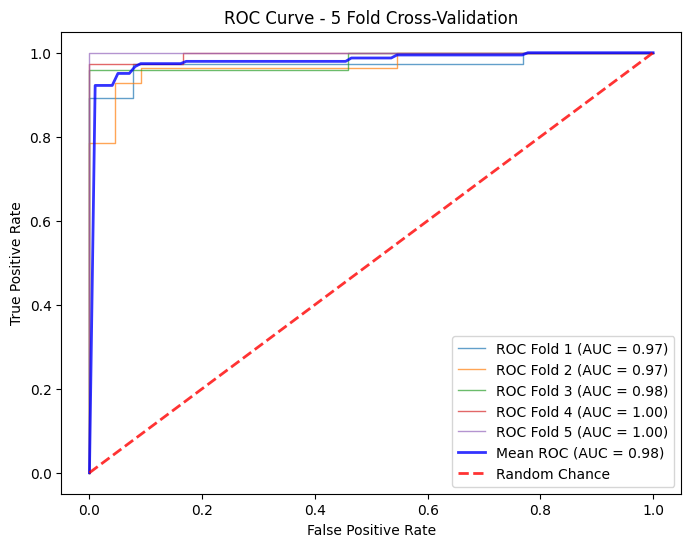

In [119]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()

In [120]:
y.value_counts()

1    165
0     82
Name: Diagnosis, dtype: int64

In [121]:
Thoda rest karlijiye warn rest in peace ho jayegene

SyntaxError: invalid syntax (119544997.py, line 1)

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))